## Q12 - Illumination Correction using Homomorphic Filtering


### Part (a) - Significance of the Multiplicative Model

An image affected by non-uniform illumination is modeled as:

$
f(x,y)=i(x,y)\cdot r(x,y)
$

where:
- $(i(x,y))$ represents the illumination component
- $(r(x,y))$ represents the reflectance component

This model is significant because it separates two different physical causes of image intensity:
- **illumination**: how light falls on the scene
- **reflectance**: how objects reflect that light

Typically, illumination varies slowly across the image and therefore corresponds mainly to **low-frequency** information. Reflectance contains object boundaries, texture, and detail, so it corresponds mainly to **high-frequency** information.

This model is useful because uneven lighting does not simply add an error to the image; instead, it scales the intensity values. That is why simple brightness or contrast adjustment is often not enough. Homomorphic filtering is designed to reduce the effect of illumination while enhancing reflectance.


### Part (b) - Logarithmic Transformation for Separating Illumination and Reflectance

Starting from the multiplicative model:

$
f(x,y)=i(x,y)\,r(x,y)
$

take the logarithm of both sides:

$
\ln f(x,y)=\ln i(x,y)+\ln r(x,y)
$

This is the key step in homomorphic filtering. The logarithmic transform converts the multiplicative model into an additive model.

This makes it possible to treat illumination and reflectance separately using linear filtering methods. Since illumination is mainly low-frequency and reflectance is mainly high-frequency, frequency-domain filtering can suppress the low-frequency component and preserve or enhance the high-frequency component.

After filtering, the inverse exponential transformation is applied to return to the image domain.


### Part (c) - Algorithm / Pseudo-code for Homomorphic Filtering

#### Pseudo-code

```text
1. Read the input image f(x,y)
2. Convert the image to floating-point format and normalize if needed
3. Add a small constant to avoid log(0)
4. Compute the log-transformed image:
      z(x,y) = log(1 + f(x,y))
5. Compute the Fourier transform:
      Z(u,v) = FFT(z(x,y))
6. Shift the zero-frequency component to the center
7. Construct a homomorphic high-pass filter H(u,v)
      - low frequencies attenuated
      - high frequencies preserved or amplified
8. Multiply in the frequency domain:
      S(u,v) = H(u,v) * Z(u,v)
9. Apply inverse frequency shift
10. Compute the inverse Fourier transform:
      s(x,y) = IFFT(S(u,v))
11. Take the real part
12. Apply inverse logarithmic transformation:
      g(x,y) = exp(s(x,y)) - 1
13. Normalize the output to display range
14. Save or display the corrected image
```

#### Typical homomorphic filter form

$
H(u,v)=(\gamma_H-\gamma_L)\left[1-e^{-c\frac{D(u,v)^2}{D_0^2}}\right]+\gamma_L
$

where:
- $(\gamma_L < 1)$ attenuates low frequencies
- $(\gamma_H > 1)$ enhances high frequencies
- $(D_0)$ is the cutoff frequency
- $(c)$ controls the sharpness of transition

This filter reduces uneven illumination and improves detail visibility.


### Part (d) - Comparison with Histogram Equalization

#### Histogram Equalization
Histogram equalization redistributes intensity values to improve global contrast.

**Advantages:**
- simple and easy to implement
- effective for general global contrast enhancement

**Limitations:**
- does not explicitly model illumination
- may over-enhance noise
- may not properly correct non-uniform lighting
- can produce unnatural brightness changes

#### Homomorphic Filtering
Homomorphic filtering explicitly uses the illumination-reflectance model.

**Advantages:**
- corrects non-uniform illumination
- enhances contrast and detail together
- is especially useful when brightness varies spatially across the image

**Limitations:**
- more complex than histogram equalization
- requires parameter tuning
- may introduce artifacts if applied too strongly

#### When Homomorphic Filtering is Preferred
Homomorphic filtering is preferred when the main problem is:
- shadows
- strong brightness gradients
- backlighting
- uneven indoor lighting
- vignetting-like darkening

Histogram equalization is more suitable when the main problem is low global contrast rather than non-uniform illumination.


### Part (e) - Applying the Method to an Image of Choice

A suitable image from the provided set is **`woman_window.jpg`**, because it clearly contains:
- a very dark interior region
- a very bright outdoor region
- strong non-uniform illumination

#### 1. Illumination Correction
Homomorphic filtering would reduce the slowly varying brightness imbalance between the dark room and the bright window. This would make the image appear more balanced overall.

#### 2. Contrast Enhancement
The method would improve visibility of details in the darker region, such as the woman’s silhouette and interior boundaries. This happens because the reflectance component is emphasized while the illumination component is reduced.

#### 3. Possible Artifacts Observed
Possible artifacts include:
- amplification of noise in darker regions
- unnatural brightness if parameters are too strong
- halo-like effects near strong edges in some cases
- slightly over-enhanced contrast if the high-frequency component is amplified too much

#### Comment
For `woman_window.jpg`, homomorphic filtering is more appropriate than simple histogram equalization because the dominant issue is uneven illumination rather than only low contrast.


## Summary

- **Part (a):** The multiplicative model separates illumination and reflectance.
- **Part (b):** The logarithm converts the multiplicative model into an additive one.
- **Part (c):** Homomorphic filtering uses log transform, frequency-domain filtering, and inverse transformation.
- **Part (d):** Homomorphic filtering is preferred when illumination is uneven.

#### Part (e) - Import Libraries and Set Paths

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

img_path = Path("../data/raw/woman_window.jpg")
out_dir = Path("../results/q12")
out_dir.mkdir(parents=True, exist_ok=True)


#### Part (e) - Load and Display the Input Image


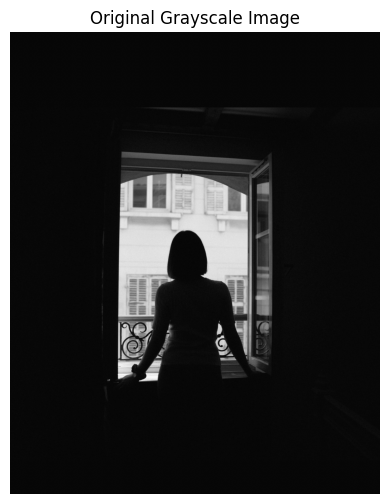

In [2]:
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


#### Part (e) - Define the Homomorphic Filter Function

In [3]:
def homomorphic_filter(img, gamma_l=0.6, gamma_h=1.8, c=1.0, d0=30):
    img = img.astype(np.float32)
    img_log = np.log1p(img)

    img_fft = np.fft.fft2(img_log)
    img_fft_shift = np.fft.fftshift(img_fft)

    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    y, x = np.ogrid[:rows, :cols]
    d2 = (y - crow) ** 2 + (x - ccol) ** 2

    h = (gamma_h - gamma_l) * (1 - np.exp(-c * d2 / (d0 ** 2))) + gamma_l

    filtered_shift = h * img_fft_shift
    filtered_ishift = np.fft.ifftshift(filtered_shift)
    img_ifft = np.fft.ifft2(filtered_ishift)
    img_exp = np.expm1(np.real(img_ifft))

    img_out = cv2.normalize(img_exp, None, 0, 255, cv2.NORM_MINMAX)
    return img_out.astype(np.uint8), h


#### Part (e) - Apply Homomorphic Filtering and Show Results

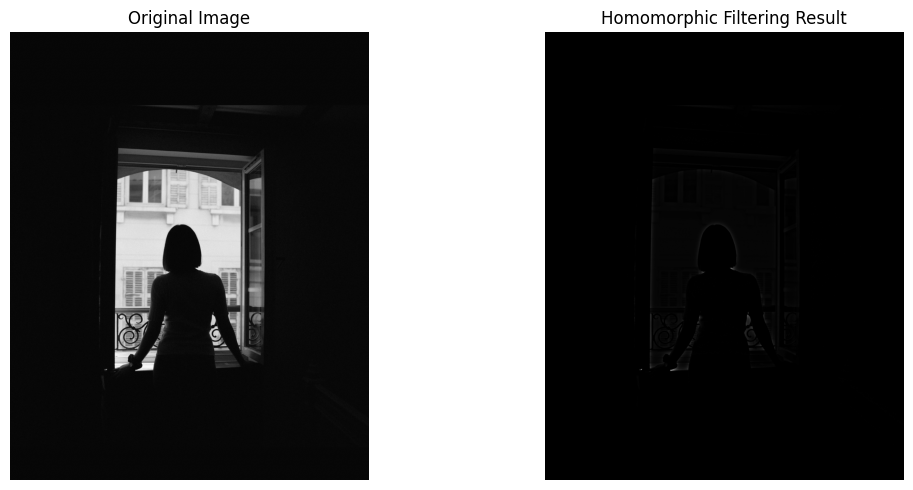

In [4]:
filtered_img, H = homomorphic_filter(
    img,
    gamma_l=0.6,
    gamma_h=1.8,
    c=1.0,
    d0=30
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_img, cmap="gray")
plt.title("Homomorphic Filtering Result")
plt.axis("off")

plt.tight_layout()
plt.show()


#### Part (e) - Display the Homomorphic Filter

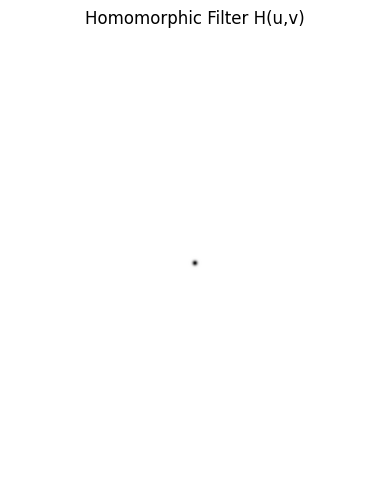

In [5]:
plt.figure(figsize=(6, 6))
plt.imshow(H, cmap="gray")
plt.title("Homomorphic Filter H(u,v)")
plt.axis("off")
plt.show()


#### Part (e) - Save the Output Images

In [6]:
cv2.imwrite(str(out_dir / "q12_original_gray.png"), img)
cv2.imwrite(str(out_dir / "q12_homomorphic_filtered.png"), filtered_img)

print(f"Saved original image to: {out_dir / 'q12_original_gray.png'}")
print(f"Saved filtered image to: {out_dir / 'q12_homomorphic_filtered.png'}")


Saved original image to: ..\results\q12\q12_original_gray.png
Saved filtered image to: ..\results\q12\q12_homomorphic_filtered.png


#### Part (e) - Comments on the Result

**Illumination correction:** The strong brightness imbalance between the dark interior and bright window region is reduced.

**Contrast enhancement:** Details in the darker region, such as the woman’s silhouette and room boundaries, become more visible.

**Artifacts observed:** If the filter parameters are too aggressive, darker regions may show amplified noise or slightly unnatural contrast.
